# Examine the data frame calculate_amplitudes_skipped_picks.csv

This notebook is used to check the data frame called calculate_amplitudes_skipped_picks.csv

Agentic AI was used in this notebook. 

By Hiroto Bito

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy import UTCDateTime
import time
from obspy.core.stream import Stream


parent_dir = '/home/hbito/cascadia_obs_ensemble/utils'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_client import get_waveforms

In [ ]:
# Prepare the file paths
datasets_dir =  '/wd1/hbito_data/data/datasets_all_regions'
path = f'{datasets_dir}/calculate_amplitudes_skipped_picks.csv'

In [3]:
skipped_picks_df = pd.read_csv(path, index_col=False).copy()
skipped_picks_df.head(10)

,network,station,channel,origin_time,time_pick,starttime,endtime,reason
0,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:05.360000Z,2010-04-30T16:04:05.360000Z,Request failed: No Vertical Component Data Pre...
1,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:27.850000Z,2010-05-01T04:21:27.850000Z,Request failed: No Vertical Component Data Pre...
2,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:07.870000Z,2010-06-22T15:52:07.870000Z,Request failed: No Vertical Component Data Pre...
3,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:04:32.760000Z,2010-07-31T04:07:32.760000Z,Request failed: No Vertical Component Data Pre...
4,UW,SP2,*H*,2010-08-09T03:50:22.194000Z,2010-08-09T03:50:52.920000Z,2010-08-09T03:50:22.920000Z,2010-08-09T03:53:22.920000Z,Request failed: No Vertical Component Data Pre...
5,UW,SP2,*H*,2010-08-11T13:06:01.021000Z,2010-08-11T13:06:19.890000Z,2010-08-11T13:05:49.890000Z,2010-08-11T13:08:49.890000Z,Request failed: No Vertical Component Data Pre...
6,BK,JCC,*H*,2011-01-06T04:29:53.238000Z,2011-01-06T04:30:04.558391Z,2011-01-06T04:29:34.558391Z,2011-01-06T04:32:34.558391Z,Request failed: No Vertical Component Data Pre...
7,BK,JCC,*H*,2011-01-06T05:52:43.509000Z,2011-01-06T05:52:50.528391Z,2011-01-06T05:52:20.528391Z,2011-01-06T05:55:20.528391Z,Request failed: No Vertical Component Data Pre...
8,BK,JCC,*H*,2011-01-06T06:27:55.741000Z,2011-01-06T06:28:02.078391Z,2011-01-06T06:27:32.078391Z,2011-01-06T06:30:32.078391Z,Request failed: No Vertical Component Data Pre...
9,BK,JCC,*H*,2011-01-06T08:14:36.764000Z,2011-01-06T08:14:46.728391Z,2011-01-06T08:14:16.728391Z,2011-01-06T08:17:16.728391Z,Request failed: No Vertical Component Data Pre...


In [4]:
skipped_picks_df['network_station'] = skipped_picks_df['network'] + '.' + skipped_picks_df['station'] + '.'
skipped_picks_df.head()

,network,station,channel,origin_time,time_pick,starttime,endtime,reason,network_station
0,UW,SP2,*H*,2010-04-30T16:01:16.639000Z,2010-04-30T16:01:35.360000Z,2010-04-30T16:01:05.360000Z,2010-04-30T16:04:05.360000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
1,UW,SP2,*H*,2010-05-01T04:18:47.446000Z,2010-05-01T04:18:57.850000Z,2010-05-01T04:18:27.850000Z,2010-05-01T04:21:27.850000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
2,UW,SP2,*H*,2010-06-22T15:49:24.169000Z,2010-06-22T15:49:37.870000Z,2010-06-22T15:49:07.870000Z,2010-06-22T15:52:07.870000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
3,UW,SP2,*H*,2010-07-31T04:04:17.592000Z,2010-07-31T04:05:02.760000Z,2010-07-31T04:04:32.760000Z,2010-07-31T04:07:32.760000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.
4,UW,SP2,*H*,2010-08-09T03:50:22.194000Z,2010-08-09T03:50:52.920000Z,2010-08-09T03:50:22.920000Z,2010-08-09T03:53:22.920000Z,Request failed: No Vertical Component Data Pre...,UW.SP2.


In [5]:
len(skipped_picks_df.drop_duplicates(subset='network_station'))

27

Plot the histogram of the stations 

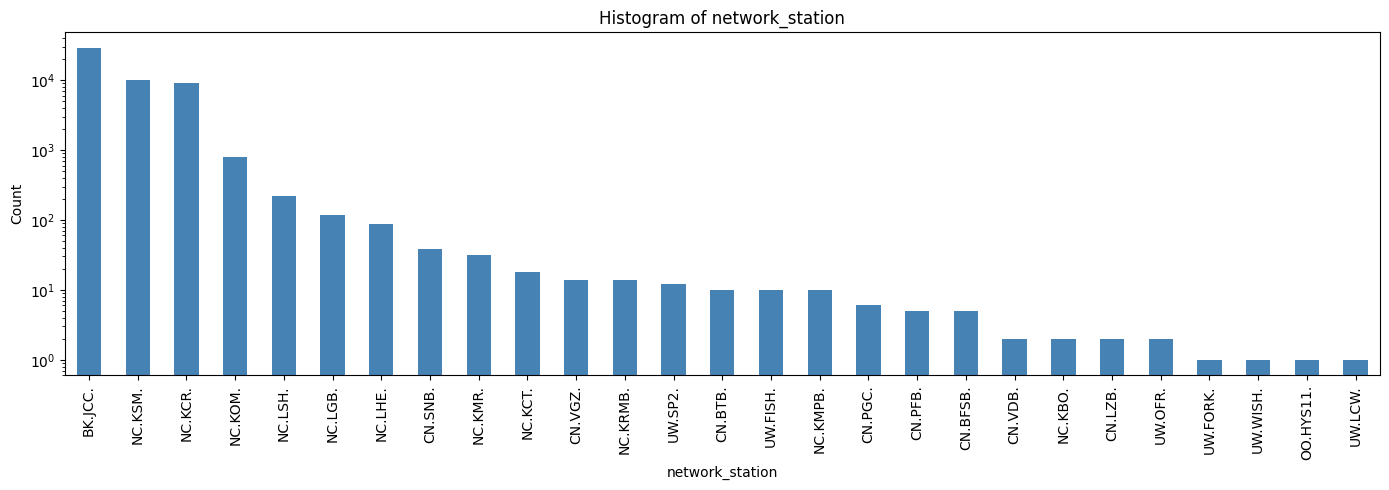

In [7]:
network_station_counts = skipped_picks_df['network_station'].value_counts()
ax = network_station_counts.plot(kind='bar', figsize=(14, 5), color='steelblue')
ax.set_title('Histogram of network_station')
ax.set_xlabel('network_station')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

Plot the histogram of the networks 

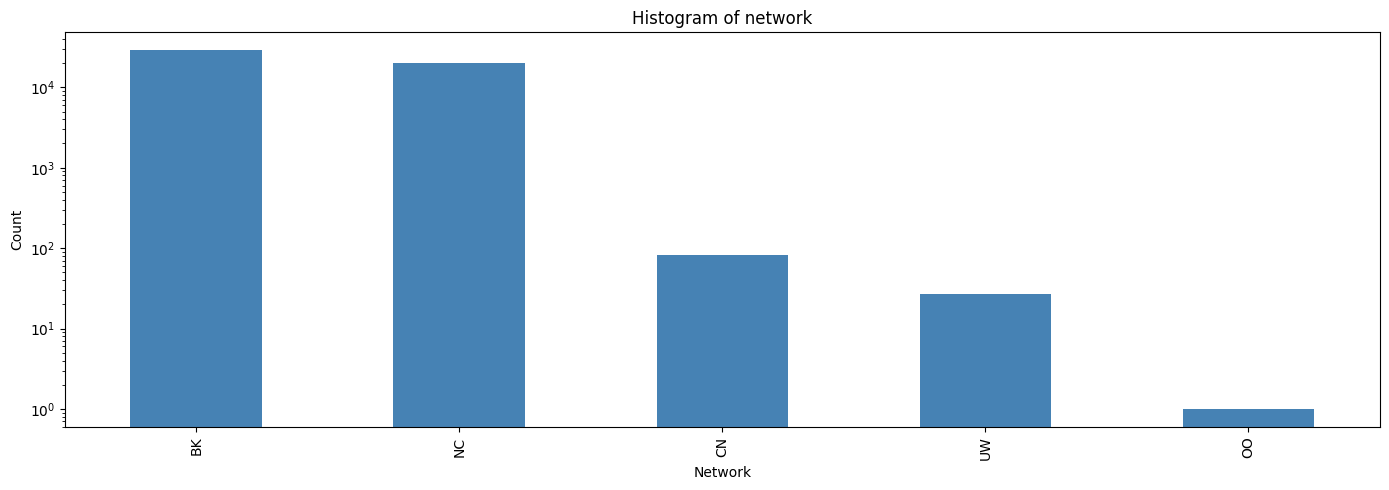

In [8]:
network_counts = skipped_picks_df['network'].value_counts()
ax = network_counts.plot(kind='bar', figsize=(14, 5), color='steelblue')
ax.set_title('Histogram of network')
ax.set_xlabel('Network')
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

Calculate the percentage of BK and NC stations in all stations

In [9]:
network_counts

BK    28877
NC    20303
CN       82
UW       27
OO        1
Name: network, dtype: int64

In [10]:
network_counts.sum()

49290

In [11]:
network_counts.keys()

Index(['BK', 'NC', 'CN', 'UW', 'OO'], dtype='object')

In [16]:
# Count the number of BK and NC stations whose picks were skipped
counts_BK_NC = network_counts['BK']+network_counts['NC']
counts_BK_NC

49180

In [13]:
# Count the total number of stations whose picks were skipped
counts_summed = network_counts.sum()
counts_summed

49290

In [14]:
# Percentage of BK and NC stations in all stations whose picks were skipped
counts_BK_NC / counts_summed

0.9977683100020288

Count the reasons the specific stations and times were skipped during the amplitude calculation

In [15]:
reason_counts = skipped_picks_df['reason'].value_counts()
reason_counts

Request failed: No data available for request.\nHTTP Status code: 204\nDetailed response of server:\n\n                                8
Request failed: No Vertical Component Data Present at NC.KSM with HHZ, BHZ or EHZ channels at 2012-08-20T12:34:45.407700Z. Skipping    2
Request failed: No Vertical Component Data Present at BK.JCC with HHZ, BHZ or EHZ channels at 2012-08-20T12:34:46.938393Z. Skipping    2
Request failed: No Vertical Component Data Present at NC.KCR with HHZ, BHZ or EHZ channels at 2012-08-20T12:34:48.287700Z. Skipping    2
Request failed: No Vertical Component Data Present at NC.KSM with HHZ, BHZ or EHZ channels at 2012-08-20T12:43:48.607700Z. Skipping    2
                                                                                                                                      ..
Request failed: No Vertical Component Data Present at NC.KCR with HHZ, BHZ or EHZ channels at 2013-12-08T20:51:50.337700Z. Skipping    1
Request failed: No Vertical Component Dat